#Code with the topic: Deviance and Residuals

#Description:

#The purpose of this code is to explain the code structure and what Deviance and Residual mean in ML 

#Technologies used:

#Python
#Pandas
#Visual Studio Code
#Juypter notebook

#Method used:

#GLM

#How to use the code?

#This code is used for educational purposes to help students understand the topic: Deviance and Residual

In [19]:
#we import the libraries

import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt



In [20]:
data = pd.read_csv("deviance_y_residuals.csv")

In [21]:
#We see our data in a table
data.head()

,feature1,feature2,feature3,target
0,34,20000,1,0
1,45,500000,0,1
2,23,15000,1,0
3,35,80000,0,1
4,52,120000,0,1


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   feature1  20 non-null     int64
 1   feature2  20 non-null     int64
 2   feature3  20 non-null     int64
 3   target    20 non-null     int64
dtypes: int64(4)
memory usage: 768.0 bytes


In [23]:
data.describe()

,feature1,feature2,feature3,target
count,20.000000,2.000000e+01,20.000000,20.000000
mean,39.500000,1.470500e+05,0.450000,0.600000
std,10.065574,2.513338e+05,0.510418,0.502625
min,23.000000,1.500000e+04,0.000000,0.000000
25%,32.500000,3.875000e+04,0.000000,0.000000
50%,38.500000,6.850000e+04,0.000000,1.000000
75%,46.500000,9.250000e+04,1.000000,1.000000
max,60.000000,1.100000e+06,1.000000,1.000000


In [24]:
#Use columns to avoid mistakes
data.columns

Index(['feature1', 'feature2', 'feature3', 'target'], dtype='object')

In [25]:
#We define our data
X = data[["feature1","feature2","feature3"]]
Y = data["target"]


In [ ]:
#We added an intercept

#What does that mean?

#You are adding a new column to your matrix X that contains only 1 in every row.

#What is this for? 

#This allows the model to learn the intercept (also known as the constant term).



X = sm.add_constant(X)

In [ ]:
#Training the model (Logistic regression)

#The model is transformed into a logistic regression

model = sm.GLM(Y,X, family=sm.families.Binomial())
results = model.fit()

c:\Users\Selene\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['famly']
  warnings.warn(msg, ValueWarning)


In [ ]:
#Predictions

#Returns probabilities
y_pred = results.predict(X)

In [ ]:
#Use of Deviance (EVALUATION)

print("Deviance:", results.deviance)
print("Null Deviance:", results.null_deviance)
#Null deviance: error from a model with no variables (only the mean)


#Deviance: measure of how well the model fits the data (lower is better)

Deviance: 1.8507679294345962
Null Deviance: 4.799999999999999


In [ ]:
#Automatic interpretation

if results.deviance < results.null_deviance:
    print("This model is better than the basic one")
else:
    print("The model isn't getting it")

El modelo es mejor que uno basico


In [ ]:
#Use of residuals

data["residual_deviance"] = results.resid_deviance

#Used for:

#✔ Analyze how well the model works
#✔ Identify difficult or anomalous cases
#✔ Save the error for each prediction


In [ ]:
#See early mistakes
#What is this for?
#This is used to perform a quick check of the model:
#you compare :
#what-really-happened (target)
#how poorly the model predicted (residual)
print("First residuals:")
print(data[["target","residual_deviance"]].head())

Primeros residuals:
   target  residual_deviance
0       0          -0.386363
1       1           0.227656
2       0           0.056586
3       1           0.558931
4       1          -0.120078


In [ ]:
#Detecting major errors:

#That line :
#✔ Look for major errors
#✔ Filter only the problematic cases
#✔ Helps you understand where the model falls short


big_mistakes = data[abs(data["residual_deviance"]) > 1]

print("Data with significant errors")
print(big_mistakes)

Datos con errores grandes
Empty DataFrame
Columns: [feature1, feature2, feature3, target, residual_deviance]
Index: []


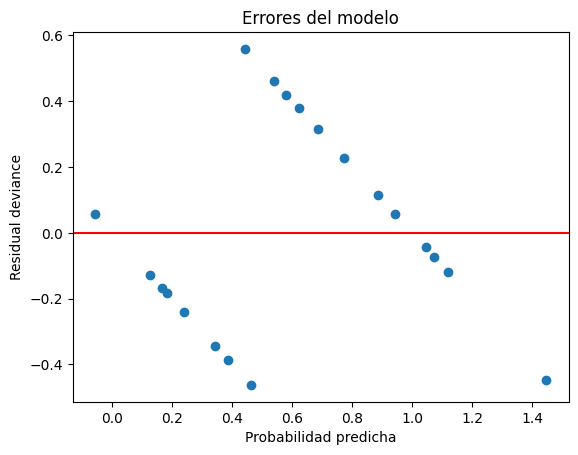

In [ ]:
#visualizacion

plt.scatter(y_pred,data["residual_deviance"])
plt.axhline(0,color = "red")
plt.xlabel("Predicted probability")
plt.ylabel("Residual deviance")
plt.title("Model errors")
plt.show()

In [ ]:
# Check if the model is good
print(results.deviance)

#see what went wrong
print(results.resid_deviance)